In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install timm albumentations opencv-python gradio matplotlib

In [ ]:
import torch
import timm
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import gradio as gr
import torch.nn.functional as F

Device Selection

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


Load the model

In [ ]:
model = timm.create_model("efficientnet_b0", pretrained=False, num_classes=4)

model.load_state_dict(
    torch.load("/content/drive/MyDrive/MRI Images/Models/best_model_fast.pth",
               map_location=device)
)

model.to(device)
model.eval()

print("Model loaded successfully")

Model loaded successfully


Tumor Class Names and Tumor Information

In [ ]:
class_names = ['glioma','meningioma','notumor','pituitary']

tumor_info = {
    "glioma": "Gliomas are tumors arising from glial cells. They can be aggressive and impact brain function depending on location.",

    "meningioma": "Meningiomas originate from brain coverings (meninges). They are typically benign and slow-growing.",

    "pituitary": "Pituitary tumors develop in the pituitary gland and may affect hormone levels and vision.",

    "notumor": "No tumor detected. The MRI appears normal."
}

In [ ]:
transform = A.Compose([
    A.Resize(256,256),
    ToTensorV2()
])


GradCAM Class

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, inp, out):
        self.activations = out.detach()

    def save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, input_tensor, class_idx=None):

        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        gradients = self.gradients.mean(dim=[2,3], keepdim=True)
        cam = (gradients * self.activations).sum(dim=1).squeeze()

        cam = torch.maximum(cam, torch.tensor(0).to(cam.device))
        cam = cam.cpu().numpy()

        cam = cv2.resize(cam,(256,256))
        cam = (cam - cam.min())/(cam.max()+1e-8)

        return cam

target_layer = model.conv_head
cam = GradCAM(model, target_layer)


Prediction Function

In [ ]:
def predict_mri(image):

    img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    raw = cv2.resize(img,(256,256))

    # Preprocessing (same as training)
    tensor = transform(image=raw)["image"].float()/255.0

    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1).to(device)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1).to(device)

    tensor = (tensor - mean) / std
    tensor = tensor.unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs,1)

    pred = probs.argmax().item()
    confidence = probs[0][pred].item()*100

    pred_class = class_names[pred]
    description = tumor_info[pred_class]

    # Extract probabilities cleanly
    glioma_p = probs[0][0].item()*100
    meningioma_p = probs[0][1].item()*100
    notumor_p = probs[0][2].item()*100
    pituitary_p = probs[0][3].item()*100

    # ================== GradCAM ==================
    heatmap = cam.generate(tensor)

    heatmap_color = cv2.applyColorMap(
        np.uint8(255*heatmap),
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(raw, 0.7, heatmap_color, 0.3, 0)

    # ================== CLEAN LABEL ==================
    label = (
        f"===== Brain Tumor Prediction Report =====\n\n"
        f"Predicted Class : {pred_class.upper()}\n"
        f"Confidence      : {confidence:.2f}%\n\n"
        f"--- Class Probabilities ---\n"
        f"Glioma      : {glioma_p:.2f}%\n"
        f"Meningioma  : {meningioma_p:.2f}%\n"
        f"No Tumor    : {notumor_p:.2f}%\n"
        f"Pituitary   : {pituitary_p:.2f}%\n\n"
        f"--- Description ---\n"
        f"{description}"
    )

    return overlay, label

Displays original MRI, Grad-CAM heatmap, and highlighted tumor regions for visualization

In [ ]:
def show_gradcam(image_path):

    img = cv2.imread(image_path)
    if img is None:
        print("❌ Image not found:", image_path)
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    raw = cv2.resize(img, (256,256))

    tensor = transform(image=raw)["image"].float()/255.0

    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1).to(device)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1).to(device)

    tensor = (tensor - mean) / std
    tensor = tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(tensor)
        probs = F.softmax(outputs, dim=1)

    pred_idx = probs.argmax(1).item()
    pred_class = class_names[pred_idx]
    confidence = probs[0][pred_idx].item() * 100

    heatmap = cam.generate(tensor)

    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * heatmap),
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    blended = cv2.addWeighted(raw, 0.7, heatmap_color, 0.3, 0)

    fig, ax = plt.subplots(1,3, figsize=(14,5))

    fig.suptitle(
        f"{pred_class.upper()} | Confidence: {confidence:.2f}%",
        fontsize=16,
        fontweight="bold"
    )

    ax[0].imshow(raw)
    ax[0].set_title("Original MRI")
    ax[0].axis("off")

    ax[1].imshow(heatmap_color)
    ax[1].set_title("Grad-CAM Heatmap")
    ax[1].axis("off")

    ax[2].imshow(blended)
    ax[2].set_title("Highlighted Region")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()


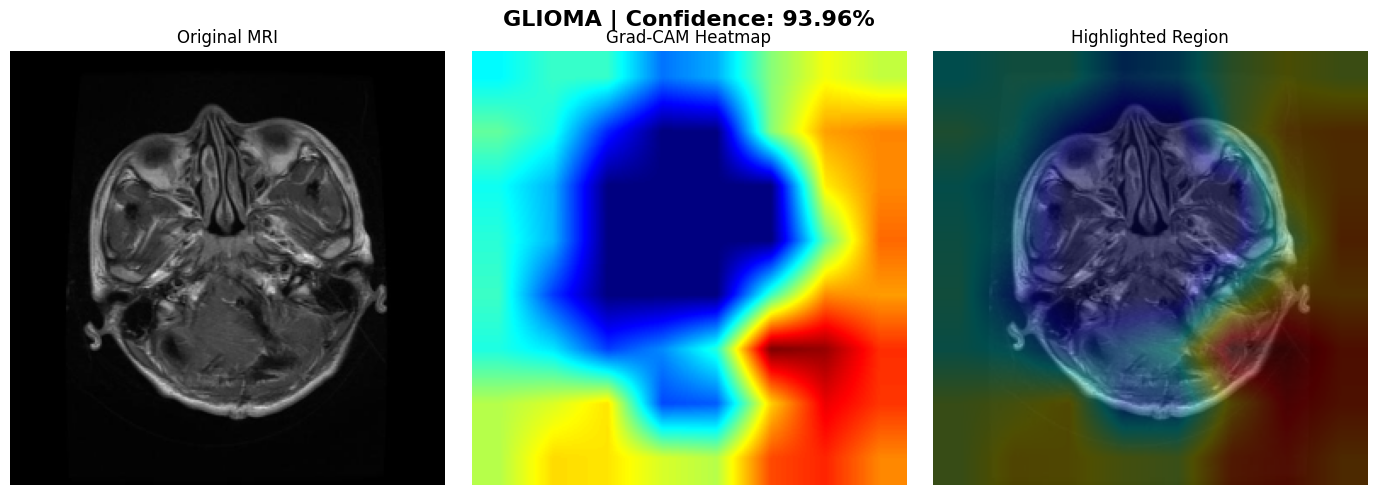

In [ ]:
show_gradcam("/content/drive/MyDrive/MRI Images/WorkingCopy/Testing/glioma/Te-gl_0029.jpg")

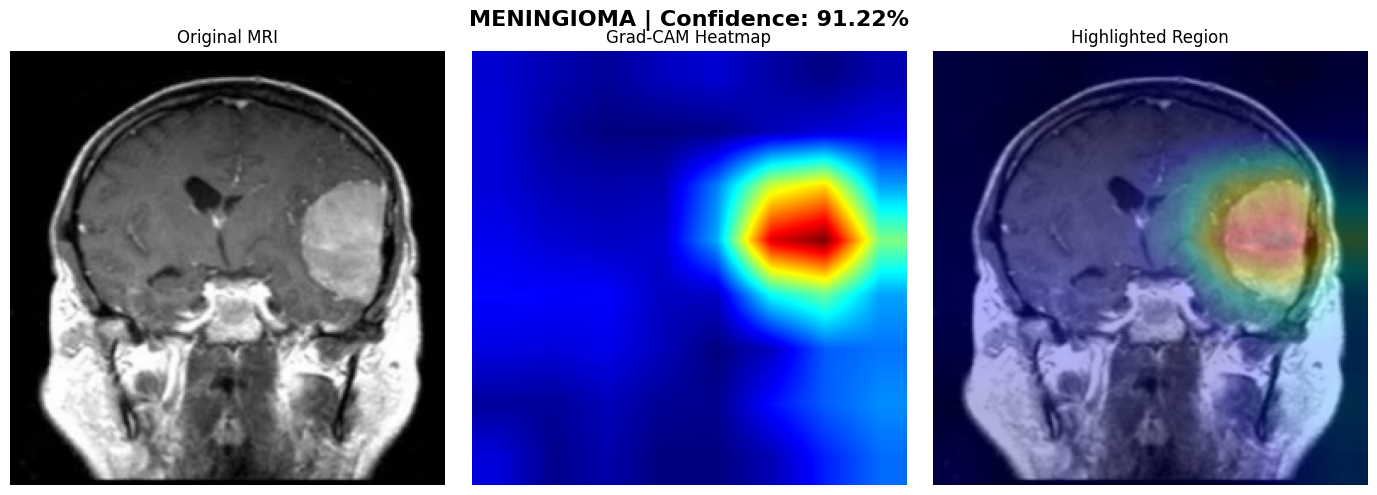

In [ ]:
show_gradcam("/content/drive/MyDrive/MRI Images/WorkingCopy/Testing/meningioma/Te-me_0016.jpg")

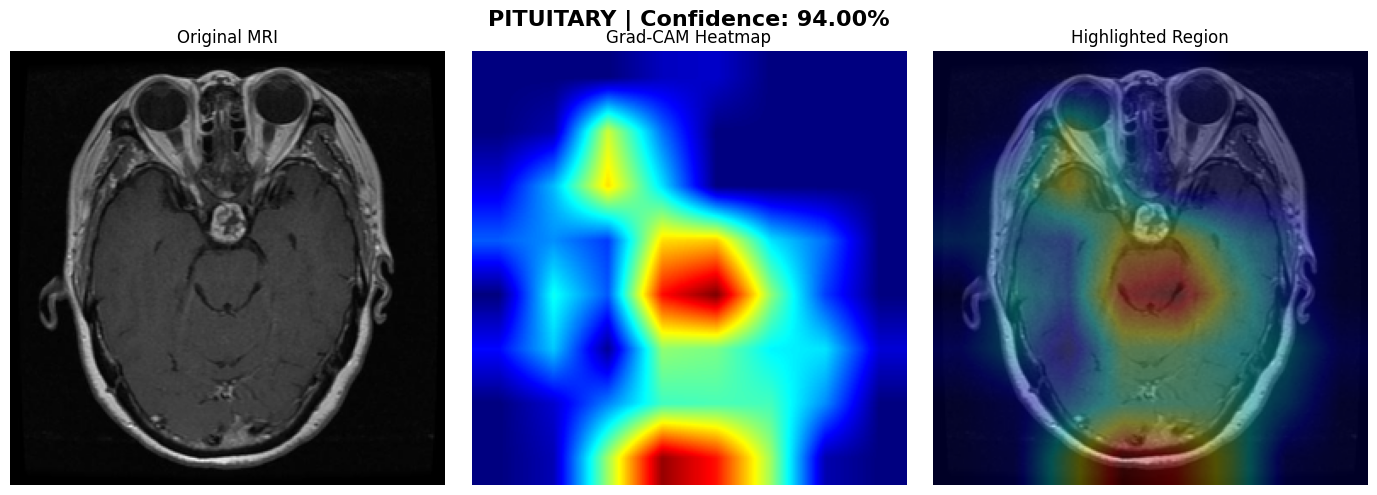

In [ ]:
show_gradcam("/content/drive/MyDrive/MRI Images/WorkingCopy/Testing/pituitary/Te-pi_0021.jpg")

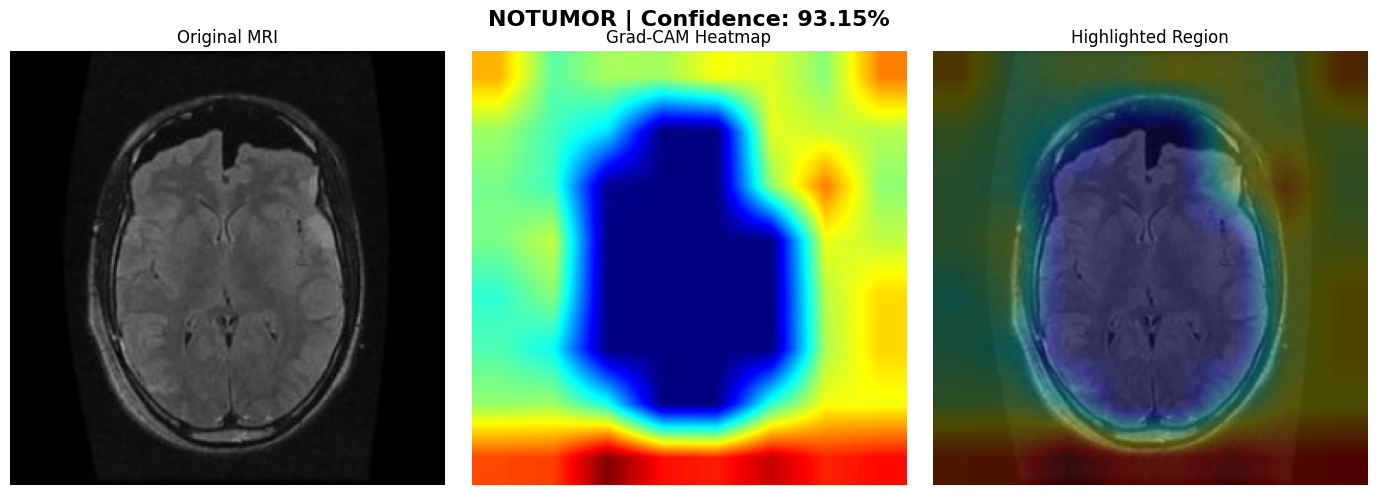

In [ ]:
show_gradcam("/content/drive/MyDrive/MRI Images/WorkingCopy/Testing/notumor/Te-no_0018.jpg")

In [ ]:
demo = gr.Interface(
    fn=predict_mri,
    inputs=gr.Image(type="pil", label="Upload MRI Image"),
    outputs=[
        gr.Image(label="Tumor Localization (Grad-CAM)"),
        gr.Textbox(label="Prediction Report", lines=15)
    ],
    title="🧠 Brain Tumor Detection System",
    description="Upload an MRI scan to classify tumor type and visualize tumor regions using Grad-CAM."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6d1cea188c34388bb5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
